In [1]:
import pandas as pd
file = "../Results/PAPER_HICCOV.csv"

In [2]:
full = pd.read_csv(file, sep="\t", header=0, index_col=0)
full

,HG002.B10M,Full,50per,40per,30per,25per,20per,15per,10per,05per
Assembly,,,,,,,,,,
# contigs (>= 0 bp),294,30,31,30,31,32,32,33,69,317
# contigs (>= 1000 bp),294,30,31,30,31,32,32,33,69,317
# contigs (>= 5000 bp),294,30,31,30,31,32,32,33,69,317
# contigs (>= 10000 bp),294,30,31,30,31,32,32,33,69,317
# contigs (>= 25000 bp),294,30,31,30,31,32,32,33,69,317
# contigs (>= 50000 bp),294,30,31,30,31,32,32,33,69,317
Total length (>= 0 bp),3051512983,3051515994,3051516083,3051515984,3051516083,3051516183,3051516183,3051516283,3051519922,3051412469
Total length (>= 1000 bp),3051512983,3051515994,3051516083,3051515984,3051516083,3051516183,3051516183,3051516283,3051519922,3051412469
Total length (>= 5000 bp),3051512983,3051515994,3051516083,3051515984,3051516083,3051516183,3051516183,3051516283,3051519922,3051412469


In [3]:
data = full.drop(columns="HG002.B10M").loc[["# misassemblies", "NGA50", "auNGA"]]
data = data.rename(columns={"Full":"100", "50per":"50", "40per":"40", "30per":"30", "25per":"25", "20per":"20", "15per":"15", "10per":"10", "05per":"5"}).T
data.index.names = ["Subsampling"]
for col in ["NGA50", "auNGA"]:
    data[col] = data[col].astype(float)/1000000
data = data.drop(index="100").reset_index(drop=False)
data["# misassemblies"] = data["# misassemblies"].astype(int)
data["Subsampling"] = data["Subsampling"].astype(int)
data["Coverage"] = data["Subsampling"]/100 * 0.12
data["X"] = [f"{data.iloc[k].Subsampling/100 * 0.12}\n({int(data.iloc[k].Subsampling)}%)" for k in range(len(data))]  
data.sort_values(by="X", inplace=True)
data

Assembly,Subsampling,# misassemblies,NGA50,auNGA,Coverage,X
7,5,106,30.218682,39.701335,0.006,0.006\n(5%)
6,10,34,100.148611,99.939887,0.012,0.012\n(10%)
5,15,3,135.899001,145.079602,0.018,0.018\n(15%)
4,20,2,154.341396,150.379452,0.024,0.024\n(20%)
3,25,2,154.341396,153.691256,0.030,0.03\n(25%)
2,30,2,154.341396,153.698513,0.036,0.036\n(30%)
1,40,3,154.341396,153.698503,0.048,0.048\n(40%)
0,50,2,154.341396,153.698519,0.060,0.06\n(50%)


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

textwidth_pt = 345  # \textwidth
columnwidth_pt = 160  # \columnwidth

# Converting to inches
textwidth_inch = textwidth_pt / 72.27
columnwidth_inch = columnwidth_pt / 72.27


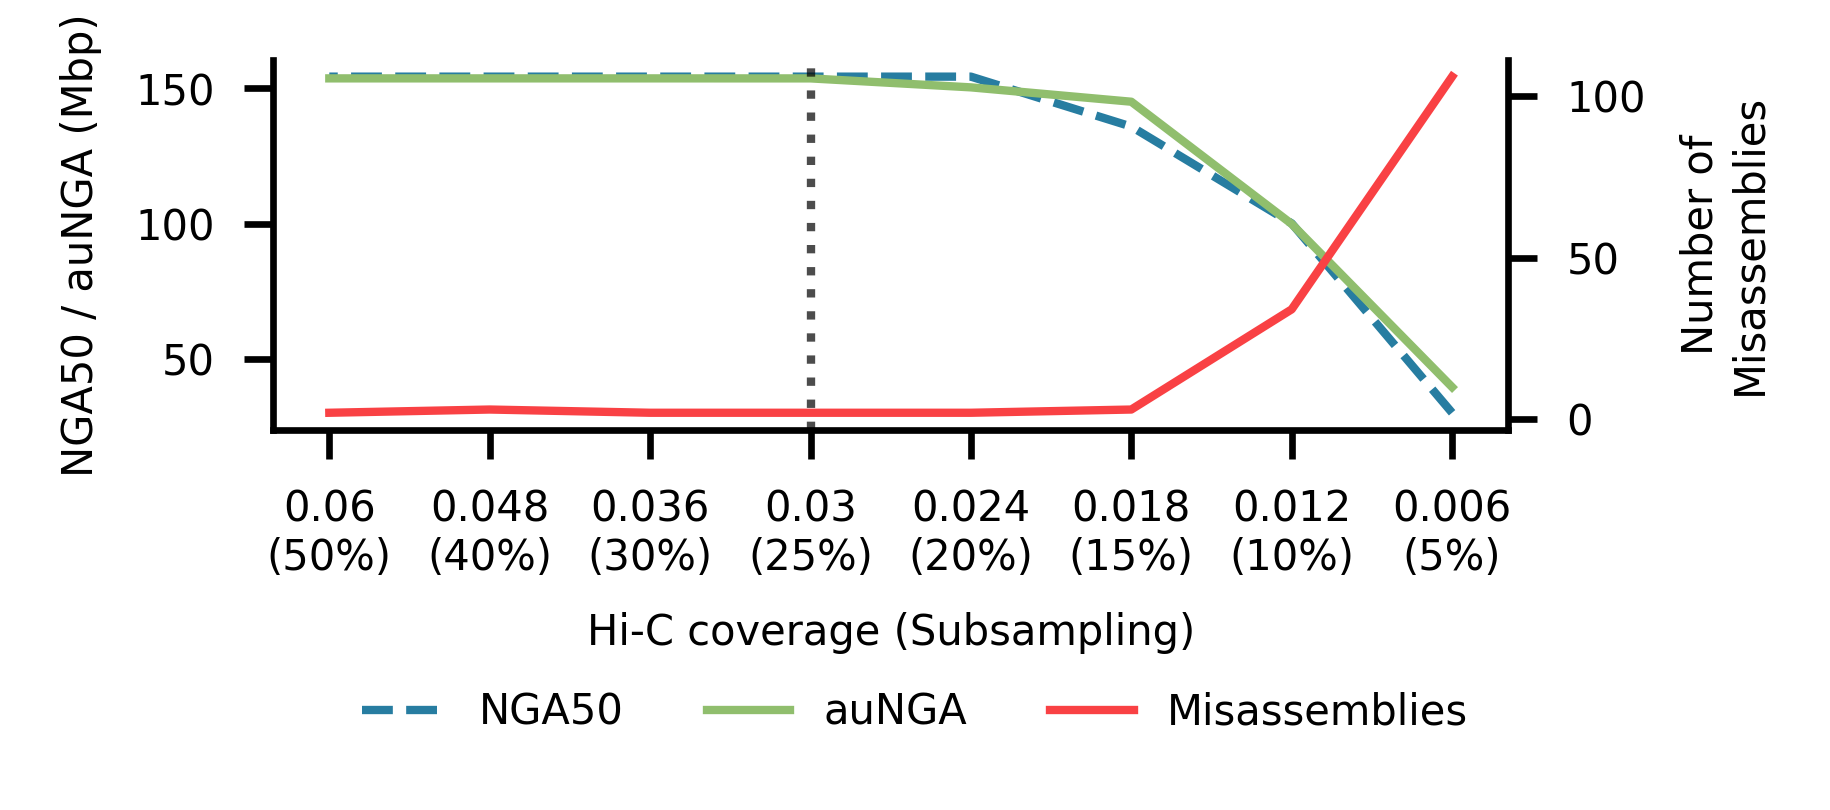

In [5]:
fs = 5
plt.rcParams.update({'font.size': fs, 'legend.fontsize':fs, 'figure.labelsize':fs})

fig, (ax1) = plt.subplots(1, 1, figsize=(3, 1.2), sharey=True, dpi=600)

sns.lineplot(x="X", y="NGA50", data=data, ax=ax1, color="#277DA1", label="NGA50", linewidth=1, linestyle="--")
sns.lineplot(x="X", y="auNGA", data=data, ax=ax1, color='#90BE6D', label="auNGA", linewidth=1)

ax2 = ax1.twinx()
sns.lineplot(data=data, x="X", y='# misassemblies', ax=ax2, color="#F94144", label='Misassemblies', linewidth=1)

ax1.set_xlabel('Hi-C coverage (Subsampling)', fontsize=fs)#, fontdict={"weight":"bold"})
ax1.set_ylabel('NGA50 / auNGA (Mbp)', fontsize=fs)#, fontdict={"weight":"bold"})
ax2.set_ylabel('Number of\nMisassemblies', fontsize=fs)#, fontdict={"weight":"bold"})

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

fig.legend(lines1 + lines2, labels1 + labels2, loc='lower center', 
           fontsize=fs, frameon=False, ncols=3, bbox_to_anchor=(.5, -0.05))
ax1.legend_.remove()
ax2.legend_.remove()

for spine in ax1.spines.values():
    spine.set_visible(False)
for spine in ax2.spines.values():
    spine.set_visible(False)
ax1.spines['left'].set_visible(True)   
ax1.spines['bottom'].set_visible(True) 
ax2.spines['right'].set_visible(True)

ax1.axvline(x=4, color='black', linestyle=':', linewidth=1, label='x = 0.030', alpha=0.7)
ax1.xaxis.set_inverted(True)

plt.tight_layout(rect=(0,0.05,1,1)) # (left, bottom, right, top)
plt.savefig("PAPER_HICCOV.png")

plt.show()